In [1]:
%matplotlib inline
import os
import sys
from os.path import join as pjoin
from tifffile import imread, imwrite, TiffFile
import numpy as np
import shutil
import matplotlib.pyplot as plt
from glob import glob
import pandas as pd
import cv2
from tqdm import tqdm
import subprocess
from scipy.ndimage import gaussian_filter,median_filter

project_root = '/home/lsh/WF_GoNogo'
if project_root not in sys.path:
    sys.path.append(project_root)
from utils.wfield_utils import *

In [2]:
os.environ['CUDA_VISIBLE_DEVICES'] = '0'
import cupy as cp
cp._default_memory_pool.free_all_blocks()

Experiments found: ['20250821-151814']
25932 25933


/home/lsh/WF_GoNogo/wf_gonogo/lib/python3.11/site-packages/tifffile/tifffile.py:1750: UserWarning: <tifffile.TiffWriter '20250821-151814-merged.tif'> writing nonconformant BigTIFF ImageJ
  warnings.warn(


Merged file saved: /home/lsh/Data_attention/Transfer learning/DATA_linshu/N098/20250821/process/20250821-151814-wfield/20250821-151814-merged.tif


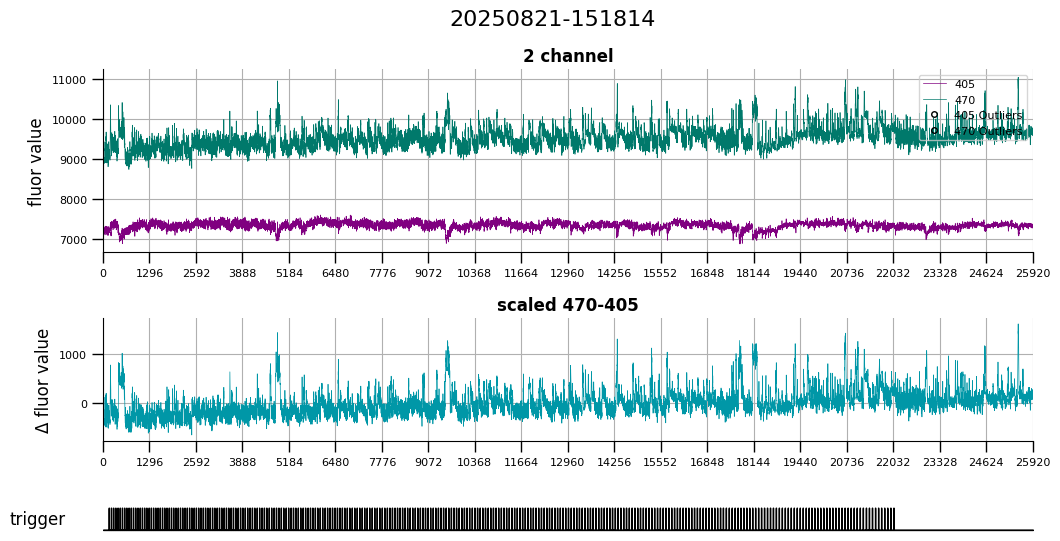

Finished merging for single day.


In [152]:
%matplotlib inline
def filename2int(filename):
    import re
    nums = re.findall(r'\d+', filename)
    return int(nums[-1]) if nums else -1

def organize_tif(folder_path, processPath):
    folder_name = os.path.basename(folder_path)
    tif_path = folder_path + '.tif'
    if os.path.exists(tif_path):
        print(f'importing {tif_path}')
        image_stack = imread(tif_path)
        print(f'finish importing {tif_path}')
    else:
        image_path_ls = glob(os.path.join(folder_path, '*.tif'))
        image_path_ls = sorted(image_path_ls, key=filename2int)
        image_stack = [imread(tiff) for tiff in image_path_ls]
    mean_values = [np.mean(frame) for frame in image_stack]
    output_value = os.path.join(processPath, folder_name + "-Values.csv")
    np.savetxt(output_value, mean_values, delimiter=",")
    return np.array(image_stack)

def merge_two_channels(rawPath, processPath, experiment):
    os.makedirs(os.path.join(processPath, experiment + "-wfield"), exist_ok=True)
    mergePath = os.path.join(processPath, experiment + "-wfield")
    merge_file = os.path.join(mergePath, experiment + "-merged.tif")
    if not os.path.exists(merge_file):
        tif_405 = organize_tif(os.path.join(rawPath, experiment + "-405"), processPath)
        tif_470 = organize_tif(os.path.join(rawPath, experiment + "-470"), processPath)
        print(tif_405.shape[0], tif_470.shape[0])

        if tif_405.shape[0] != tif_470.shape[0]:
            n_frames = min(tif_405.shape[0], tif_470.shape[0])
            tif_405 = tif_405[:n_frames]
            tif_470 = tif_470[:n_frames]
        merged_tif = np.concatenate((tif_470[:, np.newaxis], tif_405[:, np.newaxis]), axis=1)
        imwrite(merge_file, merged_tif, imagej=True, bigtiff=True)
        print(f"Merged file saved: {merge_file}")
    else:
        print(f"Merged {experiment} already exists")

        import matplotlib.pyplot as plt

import matplotlib.pyplot as plt
from tifffile import imread

# def plotFluor(path, experiment):
#     merged_file = os.path.join(path, experiment + '-wfield', experiment + '-merged.tif')
#     print("loading file:", merged_file)
#     stack = imread(merged_file)  # shape: (T, 2, H, W)
#     if stack.ndim == 4 and stack.shape[1] == 2:
#         fluor_470 = stack[:, 0, :, :]  # 通道0是470
#         mean_trace = fluor_470.mean(axis=(1, 2))  # 每帧的平均值
        
#         plt.figure(figsize=(8, 4))
#         plt.plot(mean_trace, label='470 mean F')
#         plt.xlabel('Frame')
#         plt.ylabel('Mean Fluorescence')
#         plt.title(f'{experiment}: 470通道平均荧光')
#         plt.legend()
#         plt.tight_layout()
#         plt.show()
#     else:
#         print("Stack format error or missing channels.")


# ========== 主流程 ==========

date = '20250821'
mice = 'N098'
folder_path = "/home/lsh/Data_attention/Transfer learning/DATA_linshu"
single_day_path = pjoin(folder_path,mice,date)
rawPath = single_day_path
processPath = os.path.join(single_day_path, "process")
# single_day_path = "/home/lsh/Data_attention/Transfer learning/DATA_linshu/N098/20250905"
# rawPath = single_day_path
# processPath = os.path.join(single_day_path, "process")

items = glob(os.path.join(rawPath, '202?????-??????-4*'))
experiments = list(set([os.path.basename(item)[:15] for item in items]))
print("Experiments found:", experiments)

for experiment in experiments:
    mergePath = os.path.join(processPath, experiment + "-wfield")
    merge_two_channels(rawPath, processPath, experiment)
    plotFluor(single_day_path, experiment)
    
print("Finished merging for single day.")

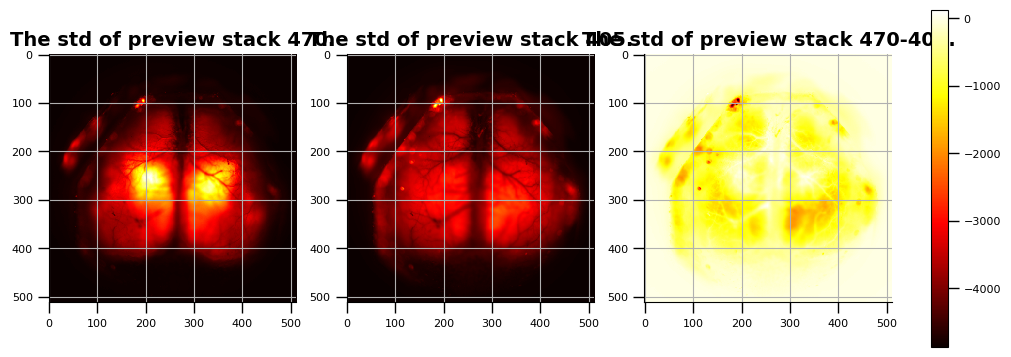

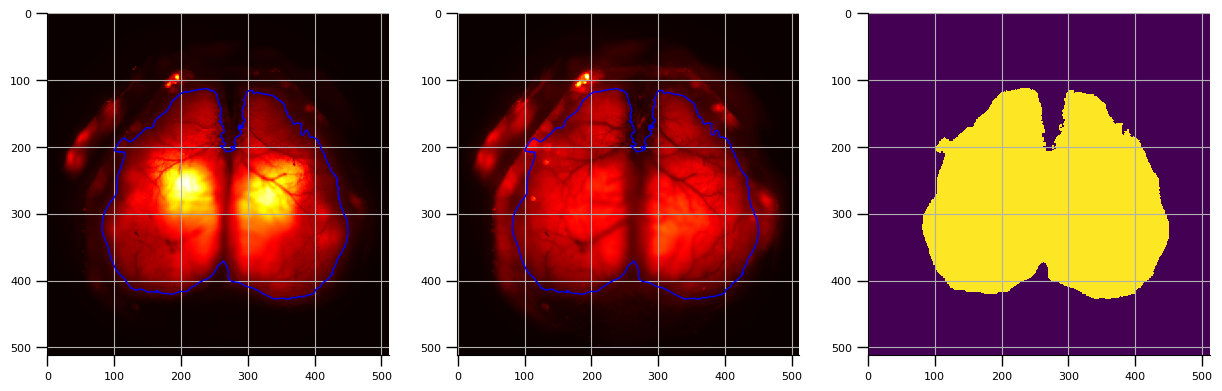

In [128]:
def show_images(images, titles=None, cmap='hot', colorbar=True):
    """
    Display a list of images side by side with a shared colorbar.

    Parameters:
    - images: list of 2D numpy arrays (images to display)
    - titles: list of strings (titles for each image)
    - cmap: string (colormap to use)
    - colorbar: bool (whether to display shared colorbar)
    """
    n = len(images)
    fig, axes = plt.subplots(1, n, figsize=(10, 4.5), constrained_layout=True)

    # 保证 axes 是可迭代的
    if n == 1:
        axes = [axes]

    # 显示图像并收集每个im对象
    im_objs = []
    for i in range(n):
        im = axes[i].imshow(images[i], cmap=cmap, aspect='equal')
        im_objs.append(im)
        if titles:
            axes[i].set_title(titles[i])
        axes[i].axis('on')  # 不显示坐标轴
        axes[i].grid()

    # 添加共享 colorbar（以最后一个im对象为准）
    if colorbar:
        fig.colorbar(im_objs[-1], ax=axes, orientation='vertical', fraction=0.02, pad=0.04)

    plt.show()

for experiment in experiments:    

    plot_test = True

    n_preview = 600
    tiff_list_470 = glob(pjoin(single_day_path, experiment + '*-470/*.tif'))[:n_preview]
    preview_stack_470 = np.array([imread(tiff) for tiff in tiff_list_470])
    tiff_list_405 = glob(pjoin(single_day_path, experiment + '*-405/*.tif'))[:n_preview]
    preview_stack_405 = np.array([imread(tiff) for tiff in tiff_list_405])
    preview_std_470 = np.std(preview_stack_470, axis=0)
    preview_std_405 = np.std(preview_stack_405, axis=0)

    if plot_test:
        images = [preview_std_470, preview_std_405, preview_std_470 - preview_std_405]
        title = ['The std of preview stack 470.', 
                'The std of preview stack 405.', 
                'The std of preview stack 470-405.']
        show_images(images, titles=title, colorbar=True)
        std_level = 250

    contour = measure.find_contours(image=preview_std_470, level=std_level)
    contour_len = [len(_contour) for _contour in contour]
    contour_max = contour[np.argmax(contour_len)]

    mask = np.zeros_like(preview_std_470)
    mask_edge = np.flip(contour_max, axis=1).astype(int)
    mask = cv2.fillPoly(mask, [mask_edge], 1)
    mergePath = os.path.join(processPath, experiment + "-wfield")
    save_path = os.path.join(mergePath, "mask.npy")
    np.save(save_path, mask)


    if plot_test:
        fig, axis = plt.subplots(figsize=(15, 5), nrows=1, ncols=3)
        
        axis[0].imshow(preview_std_470, cmap='hot')
        axis[0].plot(contour_max[:, 1], contour_max[:, 0], linewidth=1, color='blue')
        axis[0].grid()
        axis[1].imshow(preview_std_405, cmap='hot')
        axis[1].plot(contour_max[:, 1], contour_max[:, 0], linewidth=1, color='blue')
        axis[1].grid()
        axis[2].imshow(mask)
        axis[2].grid()
        plt.show()

In [129]:
pjoin(mergePath, '*-merged.tif')

'/home/lsh/Data_attention/Transfer learning/DATA_linshu/N098/20250820/process/20250820-202112-wfield/*-merged.tif'

In [130]:
import os
import numpy as np
from tifffile import imread
from os.path import join as pjoin
from tqdm import tqdm

chunk_size = 256  # 每次处理的帧数块大小

for experiment in experiments:
    mergePath = os.path.join(processPath, experiment + "-wfield")  
    print(f"Processing folder: {mergePath}")

    # 找到 tiff 文件
    tif_files = [f for f in os.listdir(mergePath) if f.endswith('-merged.tif')]
    if len(tif_files) != 1:
        print('!!! There should be exactly one merged tiff file in the folder.')
        continue
    tif_path = pjoin(mergePath, tif_files[0])

    # 读取 mask
    mask_path = os.path.join(mergePath, "mask.npy")
    mask = np.load(mask_path).astype(np.uint16)  # shape (H, W)

    # 使用 imread 读取整个 tiff 栈
    tif_stack = imread(tif_path).astype(np.uint16)  # shape (n_frames, n_channels, H, W)
    n_frames, n_channels, H, W = tif_stack.shape
    print(f"Tiff shape: {n_frames} frames, {n_channels} channels, {H}x{W}")

    # 输出 bin 文件路径
    bin_path = pjoin(mergePath, f"{n_frames}_{n_channels}_{H}_{W}_masked_uint16.bin")
    os.makedirs(os.path.dirname(bin_path), exist_ok=True)

    # 分块处理并写入二进制
    with open(bin_path, "wb") as fout:
        for start in tqdm(range(0, n_frames, chunk_size), desc="Processing chunks"):
            end = min(start + chunk_size, n_frames)
            block = tif_stack[start:end]  # shape (chunk, n_channels, H, W)
            block = block * mask[None, None, :, :]  # 广播 mask
            block.astype(np.uint16).tofile(fout)

    print('Binary file saved:', bin_path)

print('Finished generating all binary files.')


Processing folder: /home/lsh/Data_attention/Transfer learning/DATA_linshu/N098/20250820/process/20250820-202112-wfield
Tiff shape: 20760 frames, 2 channels, 512x512


Processing chunks: 100%|██████████| 82/82 [00:35<00:00,  2.29it/s]

Binary file saved: /home/lsh/Data_attention/Transfer learning/DATA_linshu/N098/20250820/process/20250820-202112-wfield/20760_2_512_512_masked_uint16.bin
Finished generating all binary files.


In [131]:
tif_stack.shape

(20760, 2, 512, 512)




Path: /home/lsh/Data_attention/Transfer learning/DATA_linshu/N098/20250820
experiment: 20250820-202112
bin_path: /home/lsh/Data_attention/Transfer learning/DATA_linshu/N098/20250820/process/20250820-202112-wfield/20760_2_512_512_masked_uint16.bin


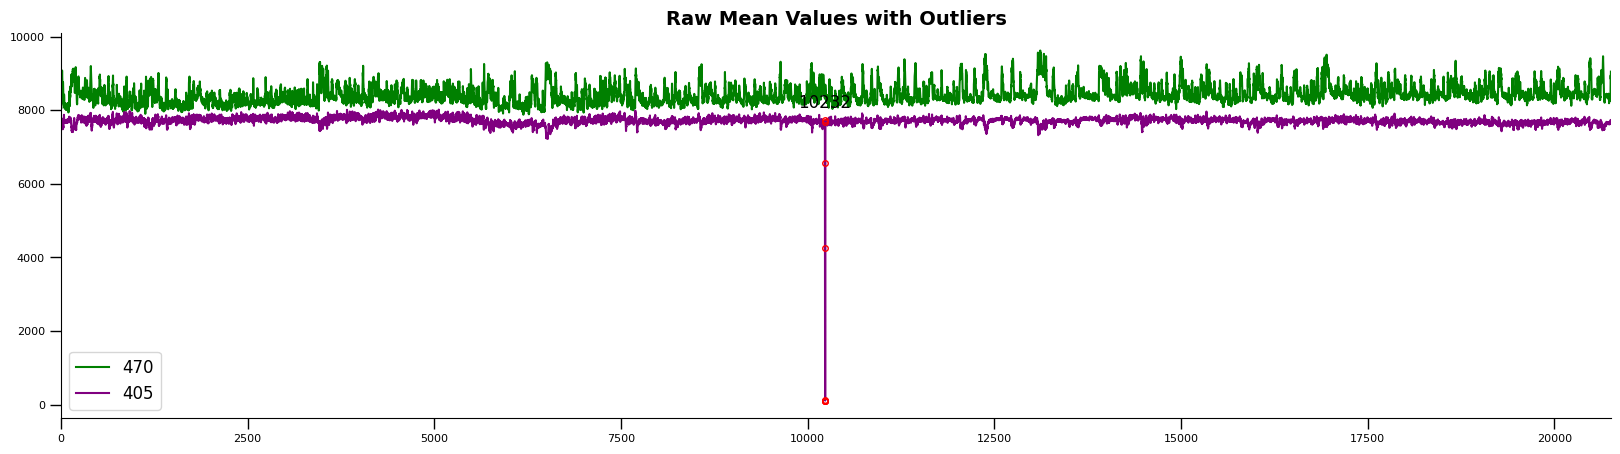

outliers detected!
Outlier index:

[[], [(np.int64(10231), np.int64(10239))]]
luminance outliers frames need to be corrected!
Luminance outliers frames corrected!


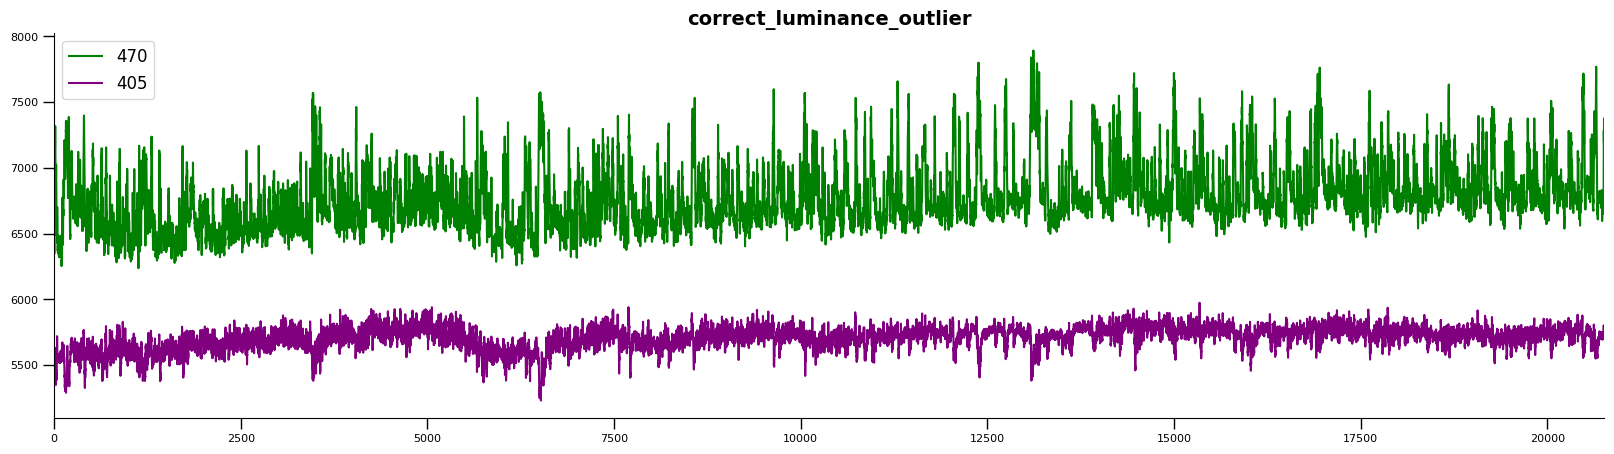

In [132]:
# detect outliers based on the mean values of 405 and 470 channels,
# and correct the outliers by averaging the values of the previous and next frames

overwrite = True
# for path in path_all:
path = single_day_path
stim_name = os.path.split(path)[-1]
    # rawPath = pjoin(path, "raw")
processPath = pjoin(path, "process")
    
items = glob(pjoin(path, '202?????-??????-4*'))
experiments = list(set([os.path.basename(item)[:15] for item in items]))

for experiment in experiments:
    print("\n\n\nPath: "+ path)
    print("experiment:", experiment)
    bin_path = glob(pjoin(processPath, experiment+"-wfield", '*uint16.bin'))[0]
    print(f'bin_path: {bin_path}')
    
    values_405_path = pjoin(path, "process", f'{experiment}-405-Values.csv')
    values_470_path = pjoin(path, "process", f'{experiment}-470-Values.csv')
    mean_values_405 = np.loadtxt(values_405_path, delimiter=',')
    mean_values_470 = np.loadtxt(values_470_path, delimiter=',')
    n_frames = min(mean_values_405.shape[0], mean_values_470.shape[0])
    mean_values_405 = mean_values_405[:n_frames]
    mean_values_470 = mean_values_470[:n_frames]
    mean_values = np.concatenate((np.expand_dims(mean_values_470, axis=1), np.expand_dims(mean_values_405, axis=1)), axis=1)
    
    outlier_index_470, outlier_index_405 = detect_outlier(mean_values, std_thr=4, plot=True)
    if len(outlier_index_470) > 0 or len(outlier_index_405) > 0:
        mean_values_corrected = correct_lum_outlier(bin_path, outlier_index_470, outlier_index_405, plot=True, overwrite=overwrite)
        np.savetxt(pjoin(path, "process", f'{experiment}-corrected values.csv'), mean_values_corrected, delimiter=",")





In [11]:
def detect_lum_outlier(mean_values, lum_thr_coef=0.3, plot=True):
    '''
    Detect outliers in the mean_values array.
    Parameters:
        mean_values: numpy array, the mean values of the image stack. 
        The first column is the mean values of 470 channel, the second column is the mean values of 405 channel.
        lum_thr_coef: luminance threshold coefficient for detecting luminance outliers.
    Returns:
        outlier_index: numpy array, the index of the outliers, 
        each row contains the start and end index of the outliers,
        the value of mean_values[start:end] is considered as outliers.
    '''
    # detecting luminance outliers
    outlier_lum_470 = mean_values[:, 0] < np.mean(mean_values[:, 0])*lum_thr_coef
    outlier_lum_idx_470 = np.where(outlier_lum_470)[0]
    if len(outlier_lum_idx_470) > 0:
        # Frames before and after the detected outliers are also considered as outliers,
        # Output index is the start and end index of the outliers,
        # Note the frame of the end index is normal, so add 2 to the end index.
        outlier_lum_idx_470 = np.array((outlier_lum_idx_470[0]-1, outlier_lum_idx_470[-1]+2))

    outlier_lum_405 = mean_values[:, 1] < np.mean(mean_values[:, 1])*lum_thr_coef
    outlier_lum_idx_405 = np.where(outlier_lum_405)[0]
    if len(outlier_lum_idx_405) > 0:
        outlier_lum_idx_405 = np.array((outlier_lum_idx_405[0]-1, outlier_lum_idx_405[-1]+2))

    outlier_index = [outlier_lum_idx_470, outlier_lum_idx_405]

    if plot:
        fig, ax = plt.subplots(figsize=(20, 5))
        ax.plot(mean_values[:, 0], label='470', color='g')
        ax.plot(mean_values[:, 1], label='405', color='purple')
        ax.set_xlim(0, len(mean_values))
        # for idx in outlier_index[0]:
        #     ax.axvline(x=idx, color='r', linestyle='--')
        # for idx in outlier_index[1]:
        #     ax.axvline(x=idx, color='r', linestyle='--')
        if len(outlier_lum_idx_470) > 0:
            ax.hlines(np.mean(mean_values[:, 0])*lum_thr_coef, 0, len(mean_values), color='g', linestyle='--')
        if len(outlier_lum_idx_405) > 0:
            ax.hlines(np.mean(mean_values[:, 1])*lum_thr_coef, 0, len(mean_values), color='purple', linestyle='--')
        ax.legend()
        plt.title('raw mean values')
        plt.show()
    
    if len(outlier_lum_idx_470) > 0 or len(outlier_lum_idx_405) > 0:
        print('\33[91mluminance outliers detected!\33[0m')
        print('luminance outlier index:\n')
        print(outlier_index)
    else:
        print('No luminance outliers detected')

    return outlier_index



def correct_lum_outlier(bin_path, outlier_index_470, outlier_index_405, overwrite=True, plot=True):
    '''
    Correct the luminance outliers frames in the merged tiff file.
    '''
    if (outlier_index_470 is not None) or (outlier_index_405 is not None):
        print('luminance outliers frames need to be corrected!')
        bin_name = os.path.splitext(os.path.basename(bin_path))[0]
        dtype = bin_name.split('_')[-1]
        # shape = tuple([int(i) for i in bin_name.split('_')[:-1]])
        shape = tuple([int(i) for i in bin_name.split('_')[:-1] if i.isdigit()])

        images = np.memmap(bin_path, dtype=dtype, mode='r+', shape=shape)
        if outlier_index_470 is not None:
            for i_outlier in outlier_index_470:
                start, end = i_outlier
                images[start:end+1, 0, :, :] = 0.5*images[start-1, 0, :, :] + 0.5*images[end+1, 0, :, :]
        if outlier_index_405 is not None:
            for i_outlier in outlier_index_405:
                start, end = i_outlier
                images[start:end+1, 1, :, :] = 0.5*images[start-1, 1, :, :] + 0.5*images[end+1, 1, :, :]
        if overwrite:
            images.flush()
            print('Luminance outliers frames corrected!')
       
    else:
        print('No luminance outliers frames to correct')


    mean_values_470 = images[:, 0, :, :].mean(axis=(1,2))
    mean_values_405 = images[:, 1, :, :].mean(axis=(1,2))
    mean_values_corrected = np.concatenate((mean_values_470[:, np.newaxis], mean_values_405[:, np.newaxis]), axis=1)    
    if plot:
        fig, ax = plt.subplots(figsize=(20, 5))
        ax.plot(mean_values_470, label='470', color='g')
        ax.plot(mean_values_405, label='405', color='purple')
        ax.set_xlim(0, len(mean_values_470))
        ax.legend()
        plt.title('correct_luminance_outlier')
        plt.show()

    return mean_values_corrected



def detect_cross_outlier(time_stamp_470, time_stamp_405, time_thr=10):
    '''
    detect the cross-channel outliers based on the time stamps of 405 and 470 channels
    cross-channel: the 405 or 470 channel frames wrongly recoreded.
    time_thr: the threshold of the vairance of the interval between the 405 and 470 channels
    '''
    diff_time = abs(time_stamp_470 - time_stamp_405)
    time_outliers_idx_advance = np.where(diff_time < (50-time_thr))[0]
    time_outliers_idx_lag = np.where(diff_time > (50+time_thr))[0] + 1

    if time_stamp_470[0] < time_stamp_405[0]: # 470 channel starts first
        return time_outliers_idx_lag, time_outliers_idx_advance
    else: # 405 channel starts first
        return time_outliers_idx_advance, time_outliers_idx_lag



def correct_cross_outlier(bin_path, outlier_index_470, outlier_index_405, overwrite=True, plot=True):
    '''
    Correct the outliers frames in the merged tiff file.
    Parameters:
        bin_path: string, the path of the bin file.
        outlier_index_405: numpy array, the index of the outliers in 405 channel.
        outlier_index_470: numpy array, the index of the outliers in 470 channel.
    '''

    if (len(outlier_index_470) > 0) or (len(outlier_index_405) > 0):
        print('cross-channel outliers frames need to be corrected!')
        bin_name = os.path.splitext(os.path.basename(bin_path))[0]
        dtype = bin_name.split('_')[-1]
        # shape = tuple([int(i) for i in bin_name.split('_')[:-1]])
        shape = tuple([int(i) for i in bin_name.split('_')[:-1] if i.isdigit()])

        images = np.memmap(bin_path, dtype=dtype, mode='r+', shape=shape)
        if len(outlier_index_470) > 0:
            for i in outlier_index_470:
                print(f'correct 470channel {i}th frame')
                images[i, 0, :, :] = 0.5*images[i-1, 0, :, :] + 0.5*images[i+1, 0, :, :]
        if len(outlier_index_405) > 0:
            for i in outlier_index_405:
                print(f'correct 405channel {i}th frame')
                images[i, 0, :, :] = 0.5*images[i-1, 0, :, :] + 0.5*images[i+1, 0, :, :] # in this case, 470 channel also need to be corrected
                # images[i, 0, :, :] = 0
                images[i, 1, :, :] = 0.5*images[i-1, 1, :, :] + 0.5*images[i+1, 1, :, :]
        if overwrite:
            images.flush() # save the changes
            print('cross-channel outliers frames corrected!')

    else:
        print('No cross-channel outliers frames to correct')

    
    mean_values_470 = images[:, 0, :, :].mean(axis=(1,2))
    mean_values_405 = images[:, 1, :, :].mean(axis=(1,2))
    mean_values_corrected = np.concatenate((mean_values_470[:, np.newaxis], mean_values_405[:, np.newaxis]), axis=1)
    if plot:
        fig, ax = plt.subplots(figsize=(20, 5))
        ax.plot(mean_values_470, label='470', color='g')
        ax.plot(mean_values_405, label='405', color='purple')
        ax.set_xlim(0, len(mean_values_470))
        ax.legend()
        plt.title('correct_cross-channel_outlier')
        plt.show()


    return mean_values_corrected



#########################################################################################################################
def detect_outlier(mean_values, std_thr=5, plot=True):
    '''
    Detect outliers in the mean_values array.
    Parameters:
        mean_values: numpy array, the mean values of the image stack. 
        The first column is the mean values of 470 channel, the second column is the mean values of 405 channel.
        std_thr: luminance threshold coefficient for detecting luminance outliers.
    Returns:
        outlier_index: list, where each element is a tuple representing a segment of outlier indices.
        Each tuple contains the start and end index of a continuous outlier segment.
    '''
    def find_continuous_outliers(outlier_lum_idx):
        """
        Helper function to find continuous segments of outliers.
        If the segment length is greater than 3, adjust start and end positions.
        """
        if len(outlier_lum_idx) == 0:
            return []

        segments = []
        start = outlier_lum_idx[0]
        
        # Iterate through outlier indices and group continuous outliers
        for i in range(1, len(outlier_lum_idx)):
            if outlier_lum_idx[i] != outlier_lum_idx[i-1] + 1:
                segments.append((start, outlier_lum_idx[i-1]))  # End the previous segment
                start = outlier_lum_idx[i]  # Start a new segment

        # Append the last segment
        segments.append((start, outlier_lum_idx[-1]))

        # Adjust the start and end positions for segments with length > 3
        adjusted_segments = []
        for segment in segments:
            start, end = segment
            if end - start + 1 > 3:  # If the segment length is greater than 3
                # Adjust start and end positions
                adjusted_start = max(start - 1, 0)  # Prevent going below 0
                adjusted_end = min(end + 1, len(mean_values) - 1)  # Prevent going above the length of the data
                adjusted_segments.append((adjusted_start, adjusted_end))
            else:
                adjusted_segments.append(segment)

        return adjusted_segments
    
    # Detecting outliers for 470 channel
    outlier_lum_470 = mean_values[:, 0] < mean_values[:, 0].mean() - std_thr * mean_values[:, 0].std()
    outlier_lum_idx_470 = np.where(outlier_lum_470)[0]
    outlier_lum_idx_470_segments = find_continuous_outliers(outlier_lum_idx_470)

    # Detecting outliers for 405 channel
    outlier_lum_405 = (mean_values[:, 1] < mean_values[:, 1].mean() - std_thr * mean_values[:, 1].std()) | (
        mean_values[:, 1] > mean_values[:, 1].mean() + std_thr * mean_values[:, 1].std())
    outlier_lum_idx_405 = np.where(outlier_lum_405)[0]
    outlier_lum_idx_405_segments = find_continuous_outliers(outlier_lum_idx_405)

    # Combine both segments
    outlier_index = [outlier_lum_idx_470_segments, outlier_lum_idx_405_segments]

    # Plot if requested
    if plot:
        fig, ax = plt.subplots(figsize=(20, 5))
        ax.plot(mean_values[:, 0], label='470', color='g')
        ax.plot(mean_values[:, 1], label='405', color='purple')
        ax.set_xlim(0, len(mean_values))

        # Plot outlier points and annotate them
        for segment in outlier_lum_idx_470_segments:
            start, end = segment
            ax.plot(np.arange(start, end+1), mean_values[start:end+1, 0], 'ko', fillstyle='none', markerfacecolor='none')
            ax.annotate(f'{start+1:.0f}', (start, mean_values[start, 0]), textcoords="offset points", xytext=(0, 10), ha='center')

        for segment in outlier_lum_idx_405_segments:
            start, end = segment
            ax.plot(np.arange(start, end+1), mean_values[start:end+1, 1], 'ro', fillstyle='none', markerfacecolor='none')
            ax.annotate(f'{start+1:.0f}', (start, mean_values[start, 1]), textcoords="offset points", xytext=(0, 10), ha='center')

        ax.legend()
        plt.title('Raw Mean Values with Outliers')
        plt.show()
    
    if len(outlier_lum_idx_470_segments) > 0 or len(outlier_lum_idx_405_segments) > 0:
        print('\33[91moutliers detected!\33[0m')
        print('Outlier index:\n')
        print(outlier_index)
    else:
        print('No outliers detected')

    return outlier_index



['/home/lsh/Data_attention/Transfer learning/DATA_linshu/N098/20250820/process/20250820-202112-wfield/20760_2_512_512_masked_uint16.bin']


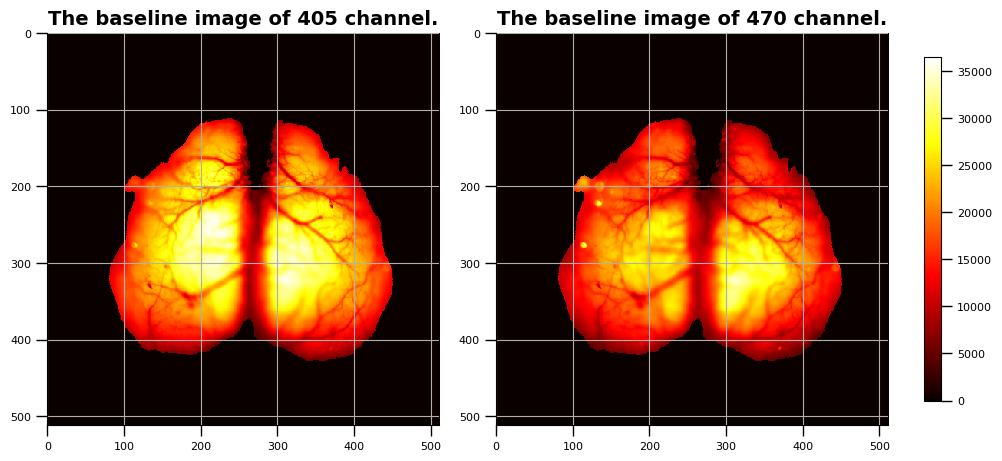

Computing SVT from the raw data: 100%|██████████| 42/42 [00:36<00:00,  1.15it/s]


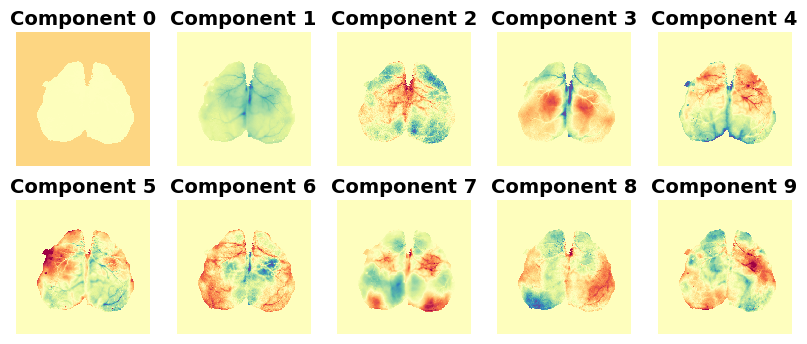

Skipping lowpass on the violet channel.
Done hemodynamic correction in 15.494840621948242 s 


In [133]:
for experiment in experiments:
    mergePath = os.path.join(processPath, experiment + "-wfield")    
    print(glob(pjoin(mergePath, '*uint16.bin')))
    dat = mmap_dat(glob(pjoin(mergePath, '*uint16.bin'))[0])
    image_base_min = np.min(dat[-300:, :, :, :], axis=0)
    np.save(pjoin(mergePath, 'frames_average.npy'), image_base_min)

    if plot_test:
        images = [image_base_min[0], image_base_min[1]]
        title = ['The baseline image of 405 channel.', 'The baseline image of 470 channel.']
        show_images(images, titles=title, colorbar=True)
    
    U, SVT = approximate_svd(dat, image_base_min)

    np.save(pjoin(mergePath,'U.npy'), U)
    np.save(pjoin(mergePath,'SVT.npy'), SVT)

    if plot_test:
        ncomponents = 10
        ncols = 5
        nrows = int(np.ceil(ncomponents/ncols))
        fig = plt.figure(figsize=[2*ncols, 2*nrows])
        for icomponent in range(ncomponents):
            fig.add_subplot(nrows, ncols, icomponent+1)
            plt.imshow(U[:, :, icomponent], clim=[-0.01,0.01],cmap='Spectral_r')
            plt.title('Component {}'.format(icomponent))
            plt.axis('off')
        plt.show()
        
    tstart = time.time()
    fs = 10
    freq_highpass = 0.001
    SVT_470 = SVT[:,0::2]
    t = np.arange(SVT.shape[1]) # interpolate the violet
    from scipy.interpolate import interp1d
    SVT_405 = interp1d(t[1::2], SVT[:,1::2], axis=1,
                        fill_value='extrapolate')(t[0::2])
    SVTcorr, rcoeffs, T = hemodynamic_correction(U, 
                                                 SVT_470, 
                                                 SVT_405, 
                                                 fs=fs,
                                                 freq_highpass=freq_highpass,
                                                 freq_lowpass=10)  

    print('Done hemodynamic correction in {0} s '.format(time.time()-tstart))
    # SVTcorr = SVT_470 - SVT_405

    # np.save(pjoin(path,'rcoeffs.npy'), rcoeffs)
    # np.save(pjoin(path,'T.npy'),T)
    np.save(pjoin(mergePath,'SVTcorr.npy'), SVTcorr)

    from scipy.signal import detrend, butter, filtfilt

    # 参数
    fs = 10  # 帧率 Hz
    highpass = 0.01  # Hz

    # 线性去趋势
    SVT_detrended = detrend(SVTcorr, axis=1)

    # 高通滤波
    b, a = butter(2, highpass/(fs/2), btype='high')
    SVT_filtered = filtfilt(b, a, SVT_detrended, axis=1)


In [134]:
SVT_filtered.shape

(200, 20760)

[6.031 5.875 5.9   5.925 5.963 5.886 5.857 5.936 5.954 5.903 5.953 5.969
 5.947 5.982 6.016 6.037 5.978 6.019 5.99  6.046 6.019 5.999 6.051 6.046
 6.028 6.087 6.055 6.044 6.072 6.089 6.085 6.08  6.09  6.096 6.102 6.084
 6.143 6.09  6.145 6.14  6.157 6.14  6.113 6.144 6.187 6.135 6.194 6.21
 6.22  6.175 6.171 6.228 6.242 6.257 6.293 6.234 6.268 6.245 6.294 6.268
 6.291 6.279 6.297 6.313 6.307 6.332 6.353 6.347 6.336 6.353 6.388 6.36
 6.351 6.375 6.352 6.416 6.372 6.395 6.404 6.409 6.365 6.403 6.421 6.408
 6.433 6.424 6.454 6.464 6.466 6.497 6.509 6.478 6.472 6.486 6.499 6.509
 6.483 6.515 6.526 6.509 6.534 6.532 6.551 6.561 6.559 6.582 6.544 6.575
 6.548 6.562 6.553 6.607 6.606 6.603 6.622 6.602 6.664 6.67  6.621 6.65
 6.632 6.675 6.659 6.68  6.677 6.656 6.662 6.732 6.722 6.705 6.73  6.683
 6.699 6.707 6.728 6.724 6.743 6.759 6.741 6.77  6.788 6.785 6.757 6.809
 6.764 6.792 6.787 6.821 6.788 6.86  6.813 6.825 6.889 6.825 6.803 6.823
 6.872 6.867 6.855 6.868 6.867 6.917 6.862 6.906 6.881

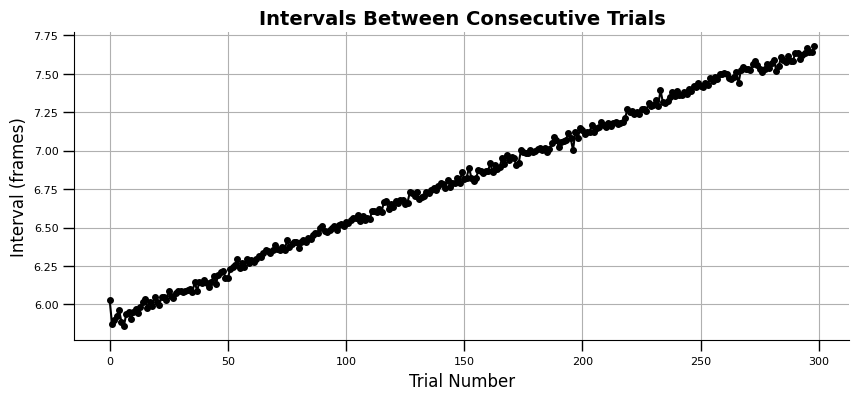

300
Generated trial_onsets.npy for 20250820-202112


In [135]:
stimfile_path = pjoin(single_day_path, experiment + ".csv")
def generate_trial_onsets(stimfile_path):
    if not os.path.exists(stimfile_path):
        print(f"{experiment} without stim-file, skip")
        return
    

    stimfile = np.loadtxt(stimfile_path, delimiter=',')
    stim_signal = stimfile[:, 0] 
    onset_indices = (np.where(np.diff(stim_signal) == 1)[0] + 1)/1000


    start_intervals = np.diff(onset_indices)
    print(start_intervals)
    plt.figure(figsize=(10, 4))
    plt.plot(start_intervals, marker='o')
    plt.xlabel('Trial Number')
    plt.ylabel('Interval (frames)')
    plt.title('Intervals Between Consecutive Trials')
    plt.grid(True)
    plt.show()
    
    print((len(onset_indices)))
    # trial_onsets = np.stack((np.arange(len(onset_indices)), onset_indices), axis=1)
    trial_onsets = onset_indices

  
    np.save(pjoin(processPath, 'trial_onsets.npy'), trial_onsets)
    print(f"Generated trial_onsets.npy for {experiment}")

    return start_intervals

start_intervals = generate_trial_onsets(stimfile_path)

In [136]:
matfile_path = glob(pjoin(single_day_path,"*.mat"))
print(matfile_path)


import scipy.io as sio

mat_data = sio.loadmat(matfile_path[0], squeeze_me=True, struct_as_record=False)


session = mat_data['SessionData']

trial_start_byBpod = session.TrialStartTimestamp
trial_end_byBpod = session.TrialEndTimestamp

print("TrialStartTimestamp shape:", trial_start_byBpod.shape)
print("TrialEndTimestamp shape:", trial_end_byBpod.shape)
trial_interval_byBpod = trial_end_byBpod - trial_start_byBpod
start_intervals_byBpod = np.diff(trial_start_byBpod)
print(start_intervals_byBpod)

['/home/lsh/Data_attention/Transfer learning/DATA_linshu/N098/20250820/N098_20250820_203418_Data_.mat']
TrialStartTimestamp shape: (300,)
TrialEndTimestamp shape: (300,)
[6.032  5.8748 5.9003 5.9251 5.9627 5.8866 5.8569 5.9364 5.9542 5.9034
 5.9532 5.9687 5.9471 5.9819 6.017  6.0364 5.9785 6.0193 5.99   6.046
 6.0195 5.9992 6.0509 6.0466 6.0282 6.0871 6.0551 6.0443 6.0715 6.0892
 6.0851 6.0806 6.0897 6.0971 6.1019 6.0837 6.1439 6.0901 6.1448 6.1402
 6.1572 6.1405 6.1123 6.1448 6.1871 6.1353 6.1938 6.21   6.2204 6.1756
 6.1709 6.2285 6.2417 6.2573 6.2935 6.2337 6.2681 6.2457 6.2941 6.2679
 6.2916 6.2792 6.2969 6.3126 6.3078 6.332  6.3536 6.3464 6.3366 6.3536
 6.3878 6.36   6.3516 6.3749 6.3524 6.4154 6.3727 6.3947 6.4048 6.4095
 6.3648 6.4029 6.4218 6.4076 6.4329 6.4249 6.454  6.4642 6.4662 6.4965
 6.5101 6.4781 6.472  6.4865 6.4988 6.5095 6.4826 6.5153 6.5259 6.5092
 6.5349 6.5318 6.5512 6.5613 6.5591 6.5821 6.5442 6.5753 6.5479 6.562
 6.5536 6.6067 6.6062 6.6034 6.6219 6.6027 6.6642 6

In [137]:
txt_path = glob(pjoin(single_day_path, '*.txt'))
trial_type = None
with open(txt_path[0]) as f:
    for line in f:
        if line.startswith("Data:"):
           
            values = line.split(":", 1)[1].strip()
            values = values.strip("[]")  
            trial_type = [int(x) for x in values.split()]

print(len(trial_type))
print(trial_type[:20]) 

300
[1, 3, 3, 1, 3, 1, 3, 1, 1, 3, 3, 1, 3, 3, 3, 3, 1, 1, 3, 3]


[ 1.00000000e-03 -2.00000000e-04  3.00000000e-04  1.00000000e-04
 -3.00000000e-04  6.00000000e-04 -1.00000000e-04  4.00000000e-04
  2.00000000e-04  4.00000000e-04  2.00000000e-04 -3.00000000e-04
  1.00000000e-04 -1.00000000e-04  1.00000000e-03 -6.00000000e-04
  5.00000000e-04  3.00000000e-04 -1.42108547e-14  2.84217094e-14
  5.00000000e-04  2.00000000e-04 -1.00000000e-04  6.00000000e-04
  2.00000000e-04  1.00000000e-04  1.00000000e-04  3.00000000e-04
 -5.00000000e-04  2.00000000e-04  1.00000000e-04  6.00000000e-04
 -3.00000000e-04  1.10000000e-03 -1.00000000e-04 -3.00000000e-04
  9.00000000e-04  1.00000000e-04 -2.00000000e-04  2.00000000e-04
  2.00000000e-04  5.00000000e-04 -7.00000000e-04  8.00000000e-04
  1.00000000e-04  3.00000000e-04 -2.00000000e-04  5.68434189e-14
  4.00000000e-04  6.00000000e-04 -1.00000000e-04  5.00000000e-04
 -3.00000000e-04  3.00000000e-04  5.00000000e-04 -3.00000000e-04
  1.00000000e-04  7.00000000e-04  1.00000000e-04 -1.00000000e-04
  6.00000000e-04  2.00000

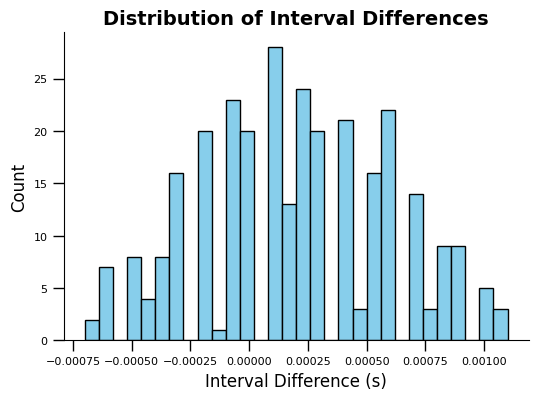

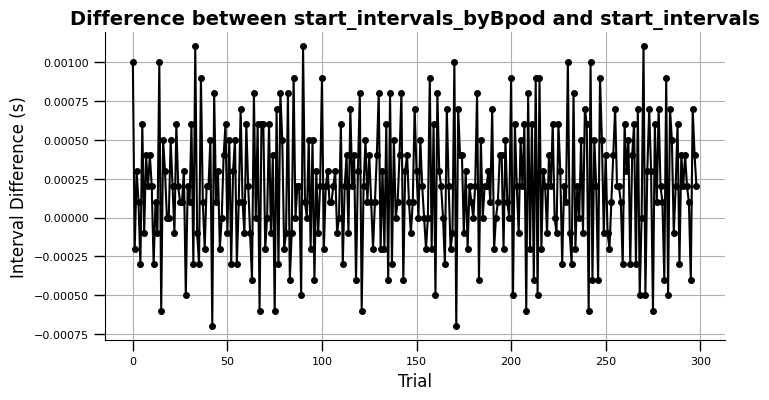

In [138]:
diff = start_intervals_byBpod-start_intervals
print(diff)
print(len(diff))
print(np.std(diff))
print(np.mean(diff))

plt.figure(figsize=(6,4))
plt.hist(diff, bins=30, color='skyblue', edgecolor='k')
plt.xlabel('Interval Difference (s)')
plt.ylabel('Count')
plt.title('Distribution of Interval Differences')
plt.show()


plt.figure(figsize=(8,4))
plt.plot(diff, marker='o', linestyle='-')
plt.xlabel('Trial')
plt.ylabel('Interval Difference (s)')  
plt.title('Difference between start_intervals_byBpod and start_intervals')
plt.grid(True)
plt.show()

In [139]:
trial_onset = np.load(pjoin(processPath, 'trial_onsets.npy'))
trial_end = trial_onset + trial_interval_byBpod
print(trial_end)

[  23.9452   29.9463   35.8213   41.7213   47.6463   53.6093   59.4953
   65.3523   71.2883   77.2423   83.1453   89.0983   95.0673  101.0143
  106.9963  113.0123  119.0493  125.0273  131.0463  137.0363  143.0823
  149.1013  155.1003  161.1513  167.1973  173.2253  179.3123  185.3673
  191.4113  197.4833  203.5723  209.6573  215.7373  221.8273  227.9233
  234.0253  240.1093  246.2523  252.3423  258.4873  264.6273  270.7843
  276.9244  283.0373  289.1813  295.3683  301.5033  307.6976  313.9073
  320.1273  326.3023  332.4733  338.7013  344.9433  351.2003  357.4936
  363.7273  369.9953  376.2403  382.5343  388.8023  395.0933  401.3723
  407.6693  413.9823  420.2893  426.6213  432.9743  439.3213  445.6573
  452.0103  458.3983  464.7583  471.1093  477.4843  483.8363  490.2523
  496.6243  503.0193  509.4235  515.8323  522.1975  528.6003  535.0213
  541.4294  547.8623  554.2863  560.7403  567.2043  573.6703  580.1673
  586.6763  593.1543  599.6262  606.1123  612.6113  619.1203  625.6032
  632.

In [140]:
trial_timestamp = np.column_stack((trial_onset, trial_end))
print(trial_timestamp)

[[  18.665    23.9452]
 [  24.696    29.9463]
 [  30.571    35.8213]
 [  36.471    41.7213]
 [  42.396    47.6463]
 [  48.359    53.6093]
 [  54.245    59.4953]
 [  60.102    65.3523]
 [  66.038    71.2883]
 [  71.992    77.2423]
 [  77.895    83.1453]
 [  83.848    89.0983]
 [  89.817    95.0673]
 [  95.764   101.0143]
 [ 101.746   106.9963]
 [ 107.762   113.0123]
 [ 113.799   119.0493]
 [ 119.777   125.0273]
 [ 125.796   131.0463]
 [ 131.786   137.0363]
 [ 137.832   143.0823]
 [ 143.851   149.1013]
 [ 149.85    155.1003]
 [ 155.901   161.1513]
 [ 161.947   167.1973]
 [ 167.975   173.2253]
 [ 174.062   179.3123]
 [ 180.117   185.3673]
 [ 186.161   191.4113]
 [ 192.233   197.4833]
 [ 198.322   203.5723]
 [ 204.407   209.6573]
 [ 210.487   215.7373]
 [ 216.577   221.8273]
 [ 222.673   227.9233]
 [ 228.775   234.0253]
 [ 234.859   240.1093]
 [ 241.002   246.2523]
 [ 247.092   252.3423]
 [ 253.237   258.4873]
 [ 259.377   264.6273]
 [ 265.534   270.7843]
 [ 271.674   276.9244]
 [ 277.787 

In [141]:
n_frames = SVT_filtered.shape[1] 
frame_times = np.arange(n_frames) / 10.0   # s
print(frame_times)


[0.0000e+00 1.0000e-01 2.0000e-01 ... 2.0757e+03 2.0758e+03 2.0759e+03]


In [142]:
trial_svt = []
for start, end in trial_timestamp:
    mask = (frame_times >= start) & (frame_times <= end)
    trial_svt.append(SVT_filtered[:, mask])

In [143]:
trial_tiff = reconstruct(U, trial_svt[266])

In [144]:
filename = pjoin(mergePath, experiment[:8] + ".h5")
print(filename)

/home/lsh/Data_attention/Transfer learning/DATA_linshu/N098/20250820/process/20250820-202112-wfield/20250820.h5


In [145]:
import h5py
with h5py.File(filename, 'w') as f:
    for i in range(len(trial_svt)):
        group_name = f"trial{i}"
        grp = f.create_group(group_name)  
        
        grp.create_dataset('trial_svt', data= trial_svt[i])
        grp.create_dataset('trial_timestamp', data = trial_timestamp[i])
        grp.create_dataset('trial_type', data = trial_type[i])
        

In [146]:
def print_h5_structure(name, obj):
    if isinstance(obj, h5py.Group):
        print(f"Group: {name}")
    elif isinstance(obj, h5py.Dataset):
        print(f"  Dataset: {name}, shape: {obj.shape}, dtype: {obj.dtype}")

with h5py.File(filename, 'r') as f:
    f.visititems(print_h5_structure)


Group: trial0
  Dataset: trial0/trial_svt, shape: (200, 53), dtype: float64
  Dataset: trial0/trial_timestamp, shape: (2,), dtype: float64
  Dataset: trial0/trial_type, shape: (), dtype: int64
Group: trial1
  Dataset: trial1/trial_svt, shape: (200, 53), dtype: float64
  Dataset: trial1/trial_timestamp, shape: (2,), dtype: float64
  Dataset: trial1/trial_type, shape: (), dtype: int64
Group: trial10
  Dataset: trial10/trial_svt, shape: (200, 53), dtype: float64
  Dataset: trial10/trial_timestamp, shape: (2,), dtype: float64
  Dataset: trial10/trial_type, shape: (), dtype: int64
Group: trial100
  Dataset: trial100/trial_svt, shape: (200, 52), dtype: float64
  Dataset: trial100/trial_timestamp, shape: (2,), dtype: float64
  Dataset: trial100/trial_type, shape: (), dtype: int64
Group: trial101
  Dataset: trial101/trial_svt, shape: (200, 52), dtype: float64
  Dataset: trial101/trial_timestamp, shape: (2,), dtype: float64
  Dataset: trial101/trial_type, shape: (), dtype: int64
Group: trial102

In [147]:
mask_path = pjoin(mergePath,'mask.npy')
mask = np.load(mask_path)

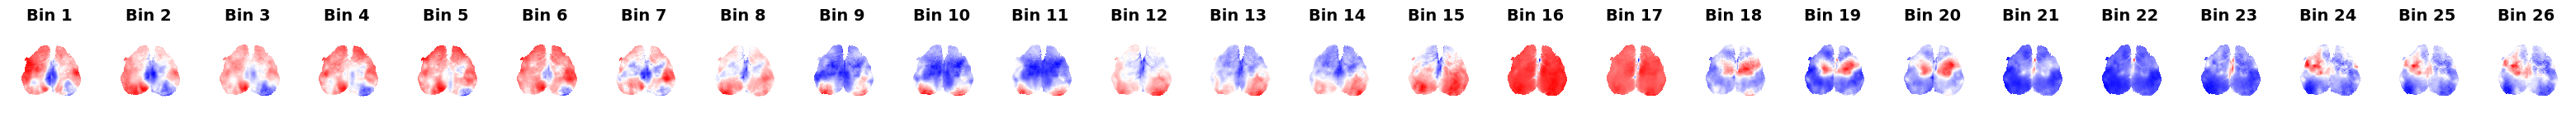

In [148]:
import numpy as np
import matplotlib.pyplot as plt

bin_size_sec = 0.2
frame_rate = 10
bin_size_frames = int(bin_size_sec * frame_rate)  
n_frames = trial_tiff.shape[0]
height, width = trial_tiff.shape[1], trial_tiff.shape[2]


n_bins = n_frames // bin_size_frames


binned_tiff = np.zeros((n_bins, height, width))
binned_tiff = np.where(mask[None, :, :], binned_tiff, np.nan)


for i in range(n_bins):
    start = i * bin_size_frames
    end = start + bin_size_frames
    binned_tiff[i] = np.where(mask, trial_tiff[start:end].mean(axis=0), np.nan)

plt.figure(figsize=(40,5))
for i in range(n_bins):
    plt.subplot(1, n_bins, i+1)
    plt.imshow(binned_tiff[i], cmap='bwr',interpolation='nearest')
    
    plt.axis('off')
    plt.title(f"Bin {i+1}")
plt.show()


In [149]:


def average_trials(trial_list):
    """输入：list of (200, n_frames)，输出：(200, min_frames)"""
    valid_trials = [trial for trial in trial_list if trial.shape[1] > 50]

    if not valid_trials:
        raise ValueError("No valid trials.")

    min_frames = min(trial.shape[1] for trial in valid_trials)
    print("Using min_frames =", min_frames)

    trimmed = [trial[:, :min_frames] for trial in valid_trials]
    return np.mean(trimmed, axis=0)

# averaged_by_type = {}

# with h5py.File(filename, 'r') as f:
#     data_by_type = {}

#     # 遍历所有 trial group
#     for group_name in f.keys():
#         grp = f[group_name]
#         svt = grp['trial_svt'][()]  # shape=(200, n_frames)
#         t_type = int(grp['trial_type'][()])
        
#         if t_type not in data_by_type:
#             data_by_type[t_type] = []
#         data_by_type[t_type].append(svt)
    
#     # 每个 trial_type 做平均
#     for t_type, svts in data_by_type.items():
#         avg_svt = average_trials(svts)
#         averaged_by_type[t_type] = avg_svt
#         print(f"trial_type {t_type}: {len(svts)} trials, "
#               f"trimmed to {avg_svt.shape[1]} frames, avg shape={avg_svt.shape}")
averaged_by_type = {}

with h5py.File(filename, 'r') as f:
    data_by_type = {}

    # 遍历所有 trial group
    for group_name in f.keys():
        grp = f[group_name]
        svt = grp['trial_svt'][()]  # shape=(200, n_frames)
        t_type = int(grp['trial_type'][()])

        if t_type not in data_by_type:
            data_by_type[t_type] = []
        data_by_type[t_type].append(svt)
    
    # 每个 trial_type 做平均
    for t_type, svts in data_by_type.items():
        avg_svt = average_trials(svts)
        # 存 tuple: (avg_svt, trial数)
        averaged_by_type[t_type] = (avg_svt, len(svts))
        print(f"trial_type {t_type}: {len(svts)} trials, "
              f"trimmed to {avg_svt.shape[1]} frames, avg shape={avg_svt.shape}")



Using min_frames = 52
trial_type 1: 115 trials, trimmed to 52 frames, avg shape=(200, 52)
Using min_frames = 52
trial_type 3: 124 trials, trimmed to 52 frames, avg shape=(200, 52)
Using min_frames = 52
trial_type 2: 35 trials, trimmed to 52 frames, avg shape=(200, 52)
Using min_frames = 52
trial_type 4: 26 trials, trimmed to 52 frames, avg shape=(200, 52)


In [150]:
import matplotlib.pyplot as plt
import numpy as np

trial_type_names = {1: 'HIT', 2: 'MISS', 3: 'FA', 4: 'CR'}

bin_size_sec = 0.2
frame_rate = 10
save_dir = (pjoin(processPath,'figure'))
os.makedirs(save_dir, exist_ok=True) 

for t_type, avg_svt in averaged_by_type.items():
    trial_tiff = reconstruct(U, avg_svt)  # shape = (n_frames, height, width)
    n_frames, height, width = trial_tiff.shape
    bin_size_frames = int(bin_size_sec * frame_rate)
    n_bins = n_frames // bin_size_frames

    binned_tiff = np.zeros((n_bins, height, width))
    for i in range(n_bins):
        start = i * bin_size_frames
        end = start + bin_size_frames
        binned_tiff[i] = trial_tiff[start:end].mean(axis=0)
        binned_tiff[i] = np.where(mask, binned_tiff[i], np.nan)

    time_bins = np.arange(n_bins) * bin_size_sec


    plt.figure(figsize=(n_bins*1.5, 5))  

    im_list = []
    for i in range(n_bins):
        ax = plt.subplot(1, n_bins, i+1)
        im = ax.imshow(binned_tiff[i], cmap='RdBu_r', interpolation='nearest')
        ax.axis('off')
        ax.set_title(f"{time_bins[i]:.1f}s", fontsize=8)  
        im_list.append(im)

    plt.colorbar(im_list[0], ax=plt.gcf().get_axes(), orientation='vertical', fraction=0.02, pad=0.01)
    plt.suptitle(f" {trial_type_names[t_type]}", fontsize=25)
    save_path = os.path.join(save_dir, f"{trial_type_names[t_type]}.png")
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()


ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (2,) + inhomogeneous part.

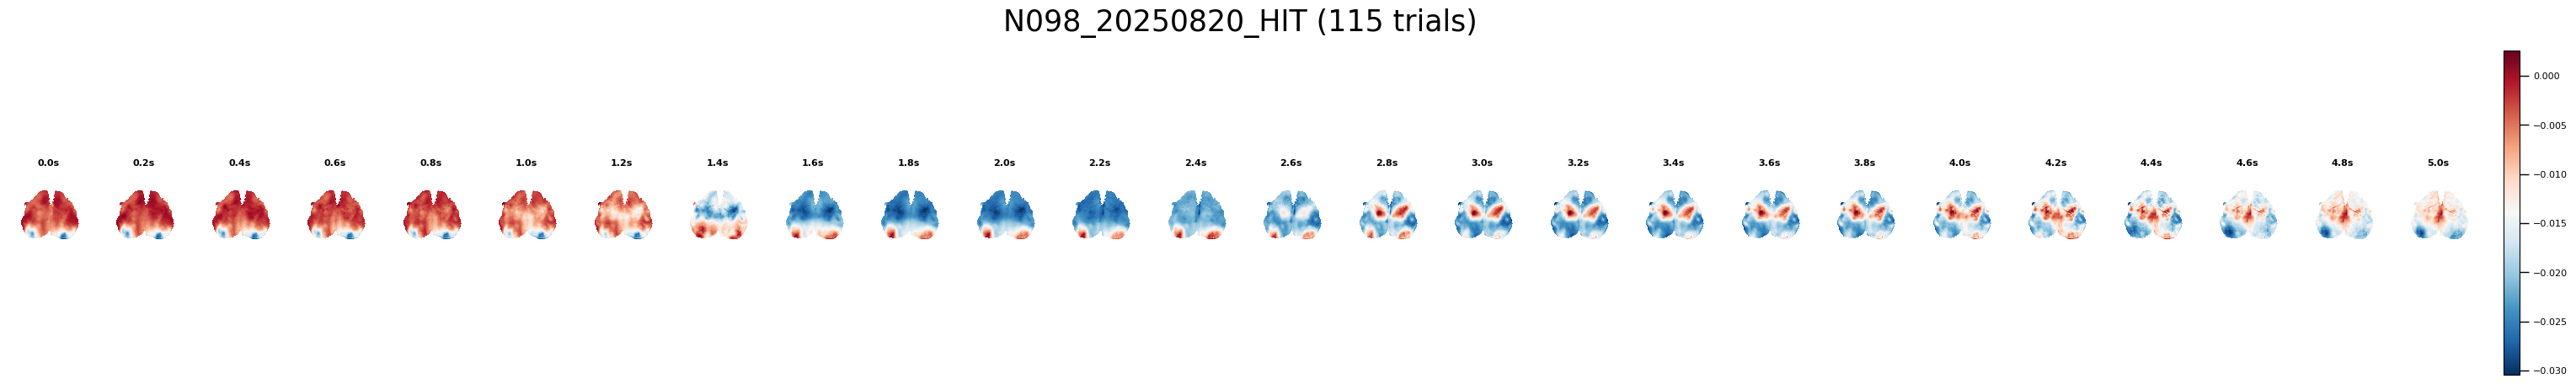

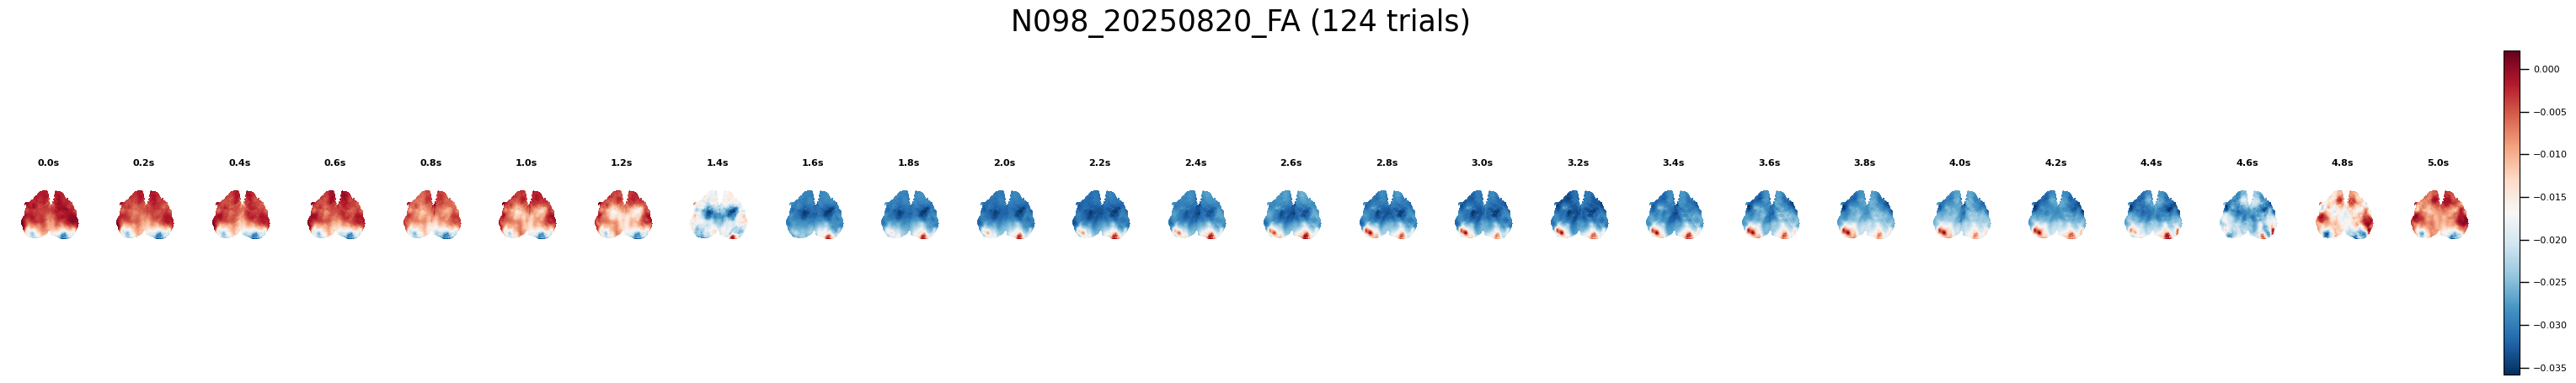

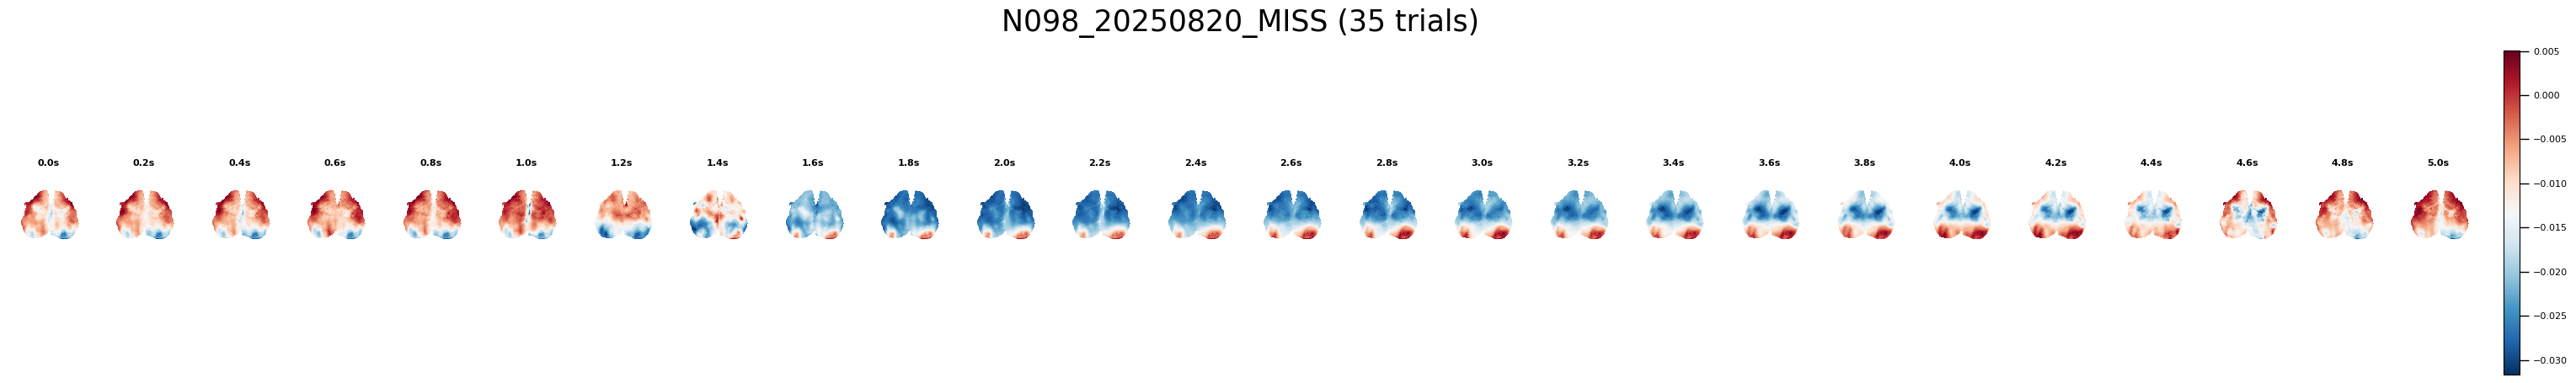

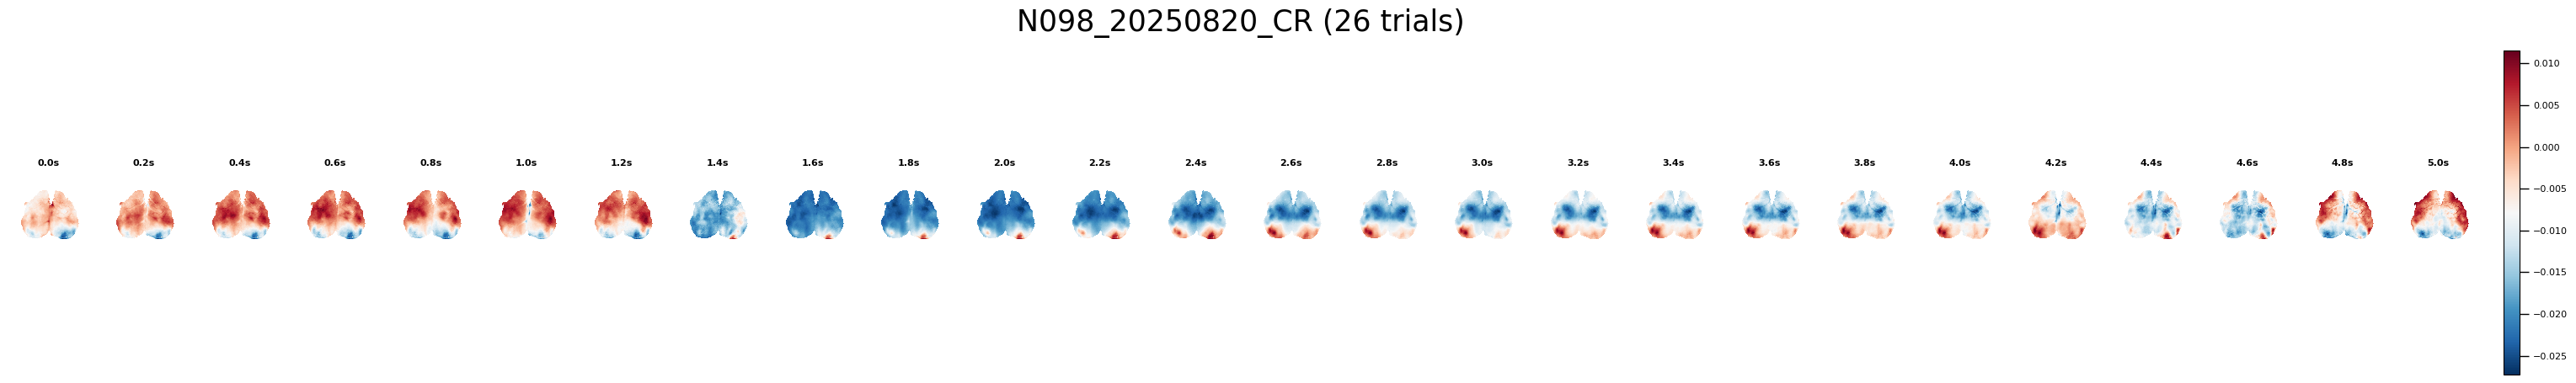

In [151]:
for t_type, (avg_svt, n_trials) in averaged_by_type.items():
    trial_tiff = reconstruct(U, avg_svt)  # shape = (n_frames, height, width)
    n_frames, height, width = trial_tiff.shape
    bin_size_frames = int(bin_size_sec * frame_rate)
    n_bins = n_frames // bin_size_frames

    binned_tiff = np.zeros((n_bins, height, width))
    for i in range(n_bins):
        start = i * bin_size_frames
        end = start + bin_size_frames
        binned_tiff[i] = trial_tiff[start:end].mean(axis=0)
        binned_tiff[i] = np.where(mask, binned_tiff[i], np.nan)

    time_bins = np.arange(n_bins) * bin_size_sec

    plt.figure(figsize=(n_bins*1.5, 5))  

    im_list = []
    for i in range(n_bins):
        ax = plt.subplot(1, n_bins, i+1)
        im = ax.imshow(binned_tiff[i], cmap='RdBu_r', interpolation='nearest')
        ax.axis('off')
        ax.set_title(f"{time_bins[i]:.1f}s", fontsize=8)  
        im_list.append(im)

    plt.colorbar(im_list[0], ax=plt.gcf().get_axes(), orientation='vertical', fraction=0.02, pad=0.01)
    plt.suptitle(f"{mice}_{date}_{trial_type_names[t_type]} ({n_trials} trials)", fontsize=25)
    save_path = os.path.join(save_dir, f"{trial_type_names[t_type]}.png")
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
